### Start Spark Session

In [9]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import *
from pyspark.sql.types import *
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import requests
import gzip
import shutil
import os
import time
from datetime import datetime

print("Starting Spark Session with UI enabled...")

# Initialize Spark with UI configuration
spark = SparkSession.builder \
    .appName("InDegreeAnalysis-Assignment") \
    .master("local[*]") \
    .config("spark.sql.adaptive.enabled", "true") \
    .config("spark.sql.adaptive.coalescePartitions.enabled", "true") \
    .config("spark.executor.memory", "2g") \
    .config("spark.driver.memory", "2g") \
    .config("spark.driver.maxResultSize", "1g") \
    .config("spark.ui.enabled", "true") \
    .config("spark.ui.port", "4040") \
    .config("spark.ui.showConsoleProgress", "true") \
    .getOrCreate()

# Set log level
spark.sparkContext.setLogLevel("WARN")

# Display Spark UI information
sc = spark.sparkContext
print(f"✓ Spark {spark.version} session created successfully!")
print(f"✓ Application ID: {sc.applicationId}")
print(f"✓ Application Name: {sc.appName}")

# Get UI URL
ui_url = getattr(sc, 'uiWebUrl', None)
if ui_url:
    print(f"✓ Spark UI URL: {ui_url}")
else:
    print("✓ Spark UI URLs to try:")
    print("  http://localhost:4040")
    print("  http://localhost:4041") 
    print("  http://localhost:4042")

print("\n" + "="*60)
print("SPARK UI IS NOW AVAILABLE!")
print("Open your browser and go to one of the URLs above")
print("Keep this kernel running to maintain Spark UI access")
print("="*60)

Starting Spark Session with UI enabled...
✓ Spark 3.3.2 session created successfully!
✓ Application ID: local-1766111019512
✓ Application Name: InDegreeAnalysis-Assignment
✓ Spark UI URL: http://host.docker.internal:4041

SPARK UI IS NOW AVAILABLE!
Open your browser and go to one of the URLs above
Keep this kernel running to maintain Spark UI access


In [8]:
spark.stop()

### In-degree analysis by dataset

Starting In-Degree Distribution Analysis using existing Spark session...

READY TO START ANALYSIS
Spark session is active and UI is available
Now running the main analysis...
Apache Spark In-Degree Distribution Analysis
Using existing Spark session: InDegreeAnalysis-Assignment

Step 1: Downloading SNAP datasets...
✓ Dataset soc-pokec already exists
✓ Dataset email-euall already exists
✓ Dataset cit-patents already exists
✓ Dataset web-berkstan already exists
✓ Dataset soc-livejournal1 already exists

Downloaded datasets:
  soc-pokec: 30,622,564 edges (404.3 MB)
  email-euall: 420,045 edges (4.8 MB)
  cit-patents: 16,518,948 edges (267.5 MB)
  web-berkstan: 7,600,595 edges (105.0 MB)
  soc-livejournal1: 68,993,773 edges (1030.5 MB)

Step 2: Initializing Spark analyzer...
✓ Spark analyzer initialized with existing session
✓ Using Spark session: InDegreeAnalysis-Assignment

Step 3: Analyzing datasets...

Analyzing soc-livejournal1...

ANALYZING: soc-livejournal1
✓ Successfully read data w

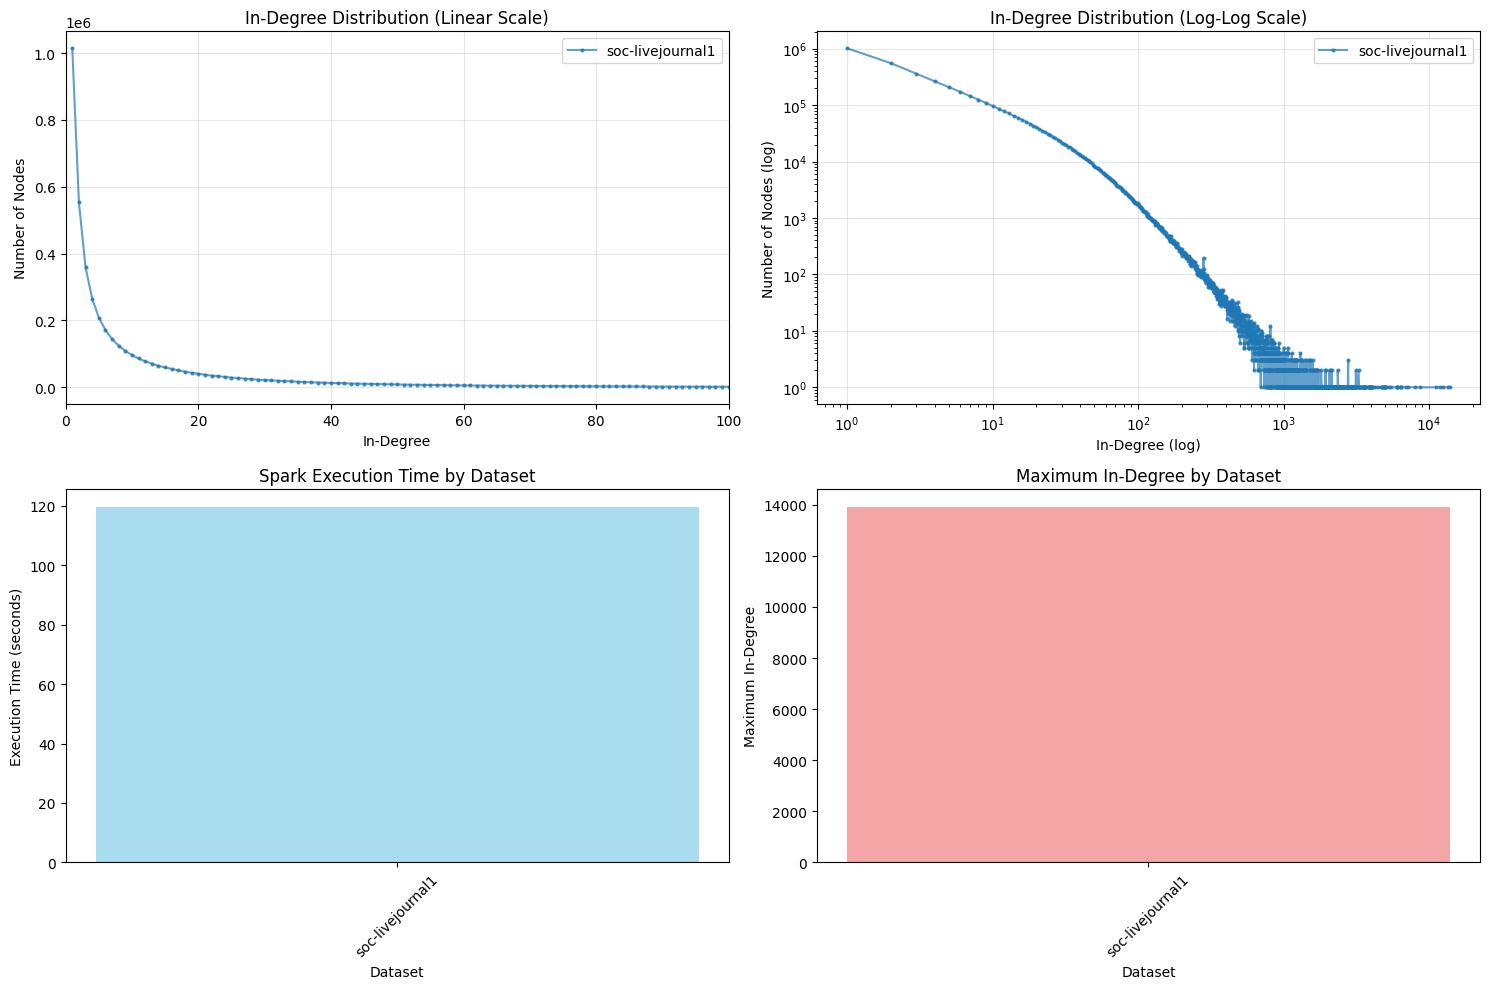


Step 5: Saving results...

ANALYSIS COMPLETED SUCCESSFULLY!
Results saved in './results/' directory
Check the generated plots and CSV files
Spark UI is still available at the URLs shown earlier


In [3]:
print("Starting In-Degree Distribution Analysis using existing Spark session...")

# Import Python's built-in functions to avoid conflicts with PySpark
from builtins import max as python_max
from builtins import min as python_min

class SnapDatasetDownloader:
    """Download and manage SNAP graph datasets"""
    
    DATASETS = {
        'soc-pokec': {
            'url': 'https://snap.stanford.edu/data/soc-pokec-relationships.txt.gz',
            'filename': 'soc-pokec-relationships.txt',
            'description': 'Social network from Pokec (Slovakia)'
        },
        'email-euall': {
            'url': 'https://snap.stanford.edu/data/email-EuAll.txt.gz',
            'filename': 'email-EuAll.txt', 
            'description': 'Email communication network'
        },
        'cit-patents': {
            'url': 'https://snap.stanford.edu/data/cit-Patents.txt.gz',
            'filename': 'cit-Patents.txt',
            'description': 'US patent citation network'
        },
        'web-berkstan': {
            'url': 'https://snap.stanford.edu/data/web-BerkStan.txt.gz',
            'filename': 'web-BerkStan.txt',
            'description': 'Web graph of Berkeley and Stanford'
        },
        'soc-livejournal1': {
            'url': 'https://snap.stanford.edu/data/soc-LiveJournal1.txt.gz',
            'filename': 'soc-LiveJournal1.txt',
            'description': 'Large social network (LiveJournal)'
        }
    }
    
    def __init__(self, data_dir='./snap_datasets'):
        self.data_dir = data_dir
        os.makedirs(data_dir, exist_ok=True)
    
    def download_dataset(self, dataset_name):
        """Download and extract a specific dataset"""
        if dataset_name not in self.DATASETS:
            raise ValueError(f"Dataset {dataset_name} not found. Available: {list(self.DATASETS.keys())}")
        
        dataset_info = self.DATASETS[dataset_name]
        gz_path = os.path.join(self.data_dir, dataset_info['filename'] + '.gz')
        txt_path = os.path.join(self.data_dir, dataset_info['filename'])
        
        # Download if not exists
        if not os.path.exists(txt_path):
            print(f"Downloading {dataset_name}...")
            try:
                response = requests.get(dataset_info['url'], stream=True, timeout=30)
                response.raise_for_status()
                
                total_size = int(response.headers.get('content-length', 0))
                downloaded_size = 0
                
                with open(gz_path, 'wb') as f:
                    for chunk in response.iter_content(chunk_size=8192):
                        if chunk:
                            f.write(chunk)
                            downloaded_size += len(chunk)
                            if total_size > 0:
                                percent = (downloaded_size / total_size) * 100
                                print(f"Progress: {percent:.1f}%", end='\r')
                
                print(f"\nExtracting {dataset_name}...")
                with gzip.open(gz_path, 'rb') as f_in:
                    with open(txt_path, 'wb') as f_out:
                        shutil.copyfileobj(f_in, f_out)
                
                # Remove gz file
                os.remove(gz_path)
                print(f"✓ Downloaded and extracted {dataset_name}")
                
            except Exception as e:
                print(f"✗ Error downloading {dataset_name}: {e}")
                if os.path.exists(gz_path):
                    os.remove(gz_path)
                return None
        else:
            print(f"✓ Dataset {dataset_name} already exists")
        
        return txt_path
    
    def download_all_datasets(self):
        """Download all SNAP datasets"""
        dataset_paths = {}
        for dataset_name in self.DATASETS:
            path = self.download_dataset(dataset_name)
            if path:
                dataset_paths[dataset_name] = path
        return dataset_paths
    
    def get_dataset_info(self, file_path):
        """Get basic information about a dataset"""
        if not os.path.exists(file_path):
            return {'edges': 0, 'size_mb': 0}
        
        edge_count = 0
        with open(file_path, 'r', encoding='utf-8', errors='ignore') as f:
            for line in f:
                if not line.startswith('#') and line.strip():
                    edge_count += 1
        
        size_mb = os.path.getsize(file_path) / (1024 * 1024)
        return {'edges': edge_count, 'size_mb': size_mb}

class SparkInDegreeAnalyzer:
    """Perform in-degree distribution analysis using existing Spark session"""
    
    def __init__(self, spark_session):
        self.spark = spark_session
        print(f"✓ Spark analyzer initialized with existing session")
        print(f"✓ Using Spark session: {spark_session.sparkContext.appName}")
    
    def analyze_dataset(self, file_path, dataset_name):
        """Analyze in-degree distribution for a dataset"""
        print(f"\n{'='*60}")
        print(f"ANALYZING: {dataset_name}")
        print(f"{'='*60}")
        
        start_time = time.time()
        
        try:
            # Check if file exists and has data
            if not os.path.exists(file_path):
                print(f"✗ File not found: {file_path}")
                return None, None
            
            # Define schema for graph data
            graph_schema = StructType([
                StructField("source", LongType(), True),
                StructField("target", LongType(), True)
            ])
            
            # Read the graph data - try different delimiters
            edges_df = None
            for delimiter in ['\t', ' ', ',']:
                try:
                    edges_df = self.spark.read \
                        .option("delimiter", delimiter) \
                        .option("comment", "#") \
                        .schema(graph_schema) \
                        .csv(file_path) \
                        .filter(col("source").isNotNull() & col("target").isNotNull())
                    
                    # Test if we got any data
                    if edges_df.count() > 0:
                        print(f"✓ Successfully read data with delimiter: '{delimiter}'")
                        break
                    else:
                        edges_df = None
                except Exception as e:
                    continue
            
            if edges_df is None:
                print("✗ Could not read data with any delimiter")
                return None, None
            
            # Cache for performance
            edges_df.cache()
            
            # Basic statistics
            total_edges = edges_df.count()
            print(f"Total edges: {total_edges:,}")
            
            if total_edges == 0:
                print("✗ No edges found in dataset!")
                edges_df.unpersist()
                return None, None
            
            # Calculate in-degree distribution
            print("Calculating in-degree distribution...")
            in_degree_df = edges_df \
                .groupBy("target") \
                .agg(count("*").alias("in_degree")) \
                .withColumnRenamed("target", "node_id")
            
            total_nodes = in_degree_df.count()
            print(f"Total nodes: {total_nodes:,}")
            
            # Calculate degree distribution
            degree_distribution_df = in_degree_df \
                .groupBy("in_degree") \
                .agg(count("*").alias("node_count")) \
                .orderBy("in_degree")
            
            # Calculate comprehensive statistics
            stats_df = in_degree_df.agg(
                count("*").alias("total_nodes"),
                max("in_degree").alias("max_in_degree"),
                min("in_degree").alias("min_in_degree"),
                mean("in_degree").alias("avg_in_degree"),
                expr("percentile_approx(in_degree, 0.5)").alias("median_in_degree"),
                expr("percentile_approx(in_degree, 0.95)").alias("p95_in_degree")
            )
            
            # Collect results
            execution_time = time.time() - start_time
            stats_row = stats_df.collect()[0]
            degree_distribution_pandas = degree_distribution_df.toPandas()
            
            # Performance metrics
            metrics = {
                'dataset': dataset_name,
                'file_path': file_path,
                'execution_time_seconds': execution_time,
                'total_edges': total_edges,
                'total_nodes': total_nodes,
                'max_in_degree': stats_row['max_in_degree'],
                'min_in_degree': stats_row['min_in_degree'],
                'avg_in_degree': float(stats_row['avg_in_degree']) if stats_row['avg_in_degree'] is not None else 0,
                'median_in_degree': float(stats_row['median_in_degree']) if stats_row['median_in_degree'] is not None else 0,
                'p95_in_degree': float(stats_row['p95_in_degree']) if stats_row['p95_in_degree'] is not None else 0
            }
            
            # Print summary
            self._print_analysis_summary(metrics, degree_distribution_pandas)
            
            # Clean up
            edges_df.unpersist()
            
            return metrics, degree_distribution_pandas
            
        except Exception as e:
            print(f"✗ Error during analysis: {e}")
            import traceback
            traceback.print_exc()
            return None, None
    
    def _print_analysis_summary(self, metrics, degree_distribution):
        """Print analysis summary"""
        print(f"\n--- Analysis Summary for {metrics['dataset']} ---")
        print(f"Execution time: {metrics['execution_time_seconds']:.2f} seconds")
        print(f"Total edges: {metrics['total_edges']:,}")
        print(f"Total nodes: {metrics['total_nodes']:,}")
        print(f"Max in-degree: {metrics['max_in_degree']:,}")
        print(f"Average in-degree: {metrics['avg_in_degree']:.2f}")
        print(f"Median in-degree: {metrics['median_in_degree']:.2f}")
        print(f"95th percentile: {metrics['p95_in_degree']:.2f}")
        
        if len(degree_distribution) > 0:
            # Show degree distribution characteristics
            low_degree = degree_distribution[degree_distribution['in_degree'] <= 5]['node_count'].sum()
            high_degree = degree_distribution[degree_distribution['in_degree'] > 20]['node_count'].sum()
            
            low_percent = (low_degree / metrics['total_nodes']) * 100
            high_percent = (high_degree / metrics['total_nodes']) * 100
            
            print(f"Nodes with degree ≤ 5: {low_degree:,} ({low_percent:.1f}%)")
            print(f"Nodes with degree > 20: {high_degree:,} ({high_percent:.1f}%)")
            
            if low_percent > 70 and high_percent < 10:
                print("→ This network exhibits power-law characteristics")
            
            print(f"\nTop 5 most frequent degrees:")
            top_degrees = degree_distribution.nlargest(5, 'node_count')
            for _, row in top_degrees.iterrows():
                percent = (row['node_count'] / metrics['total_nodes']) * 100
                print(f"  Degree {row['in_degree']}: {row['node_count']:,} nodes ({percent:.2f}%)")

class PerformanceVisualizer:
    """Visualize analysis results"""
    
    def __init__(self, output_dir='./results'):
        self.output_dir = output_dir
        os.makedirs(output_dir, exist_ok=True)
    
    def plot_degree_distributions(self, results, figsize=(15, 10)):
        """Plot degree distributions for all datasets"""
        if not results:
            print("No results to visualize")
            return
            
        plt.figure(figsize=figsize)
        
        # Plot 1: Linear scale
        plt.subplot(2, 2, 1)
        for dataset_name, (metrics, dist_df) in results.items():
            if len(dist_df) > 0:
                plt.plot(dist_df['in_degree'], dist_df['node_count'], 'o-', 
                        label=dataset_name, alpha=0.7, markersize=2)
        plt.xlabel('In-Degree')
        plt.ylabel('Number of Nodes')
        plt.title('In-Degree Distribution (Linear Scale)')
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        # Set x-axis limits safely using Python's built-in max
        if results:
            max_degrees = []
            for _, dist_df in results.values():
                if len(dist_df) > 0:
                    max_degrees.append(dist_df['in_degree'].max())
            if max_degrees:
                # Use explicitly imported python_max
                max_degree_value = python_max(max_degrees)
                plt.xlim(0, python_min(100, max_degree_value))
        
        # Plot 2: Log-log scale
        plt.subplot(2, 2, 2)
        for dataset_name, (metrics, dist_df) in results.items():
            if len(dist_df) > 0:
                # Filter out zeros for log plot
                plot_df = dist_df[(dist_df['in_degree'] > 0) & (dist_df['node_count'] > 0)]
                if len(plot_df) > 0:
                    plt.loglog(plot_df['in_degree'], plot_df['node_count'], 'o-', 
                              label=dataset_name, alpha=0.7, markersize=2)
        plt.xlabel('In-Degree (log)')
        plt.ylabel('Number of Nodes (log)')
        plt.title('In-Degree Distribution (Log-Log Scale)')
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        # Plot 3: Execution times
        plt.subplot(2, 2, 3)
        execution_times = [metrics['execution_time_seconds'] for metrics, _ in results.values()]
        datasets = list(results.keys())
        plt.bar(datasets, execution_times, color='skyblue', alpha=0.7)
        plt.xlabel('Dataset')
        plt.ylabel('Execution Time (seconds)')
        plt.title('Spark Execution Time by Dataset')
        plt.xticks(rotation=45)
        
        # Plot 4: Max in-degrees
        plt.subplot(2, 2, 4)
        max_degrees = [metrics['max_in_degree'] for metrics, _ in results.values()]
        plt.bar(datasets, max_degrees, color='lightcoral', alpha=0.7)
        plt.xlabel('Dataset')
        plt.ylabel('Maximum In-Degree')
        plt.title('Maximum In-Degree by Dataset')
        plt.xticks(rotation=45)
        
        plt.tight_layout()
        plt.savefig(f'{self.output_dir}/degree_distributions.png', dpi=300, bbox_inches='tight')
        plt.show()
    
    def create_performance_table(self, results):
        """Create a performance summary table"""
        performance_data = []
        for dataset_name, (metrics, _) in results.items():
            performance_data.append({
                'Dataset': dataset_name,
                'Edges': f"{metrics['total_edges']:,}",
                'Nodes': f"{metrics['total_nodes']:,}",
                'Execution Time (s)': f"{metrics['execution_time_seconds']:.2f}",
                'Max In-Degree': f"{metrics['max_in_degree']:,}",
                'Avg In-Degree': f"{metrics['avg_in_degree']:.2f}",
                'Median In-Degree': f"{metrics['median_in_degree']:.2f}"
            })
        
        return pd.DataFrame(performance_data)

# Main execution function that uses the existing Spark session
def run_analysis_with_existing_spark(spark_session):
    """Run the complete analysis using the existing Spark session"""
    print("Apache Spark In-Degree Distribution Analysis")
    print("=" * 60)
    print(f"Using existing Spark session: {spark_session.sparkContext.appName}")
    
    # Step 1: Download datasets
    print("\nStep 1: Downloading SNAP datasets...")
    downloader = SnapDatasetDownloader('./snap_datasets')
    dataset_paths = downloader.download_all_datasets()
    
    print("\nDownloaded datasets:")
    for name, path in dataset_paths.items():
        if path:
            info = downloader.get_dataset_info(path)
            print(f"  {name}: {info['edges']:,} edges ({info['size_mb']:.1f} MB)")
    
    # Step 2: Initialize Spark analyzer with existing session
    print("\nStep 2: Initializing Spark analyzer...")
    analyzer = SparkInDegreeAnalyzer(spark_session)
    
    # Step 3: Analyze datasets (start with smaller ones first)
    print("\nStep 3: Analyzing datasets...")
    # Start with smaller datasets first
    analysis_order = ['soc-livejournal1']  # web-berkstan and soc-livejournal1 are very large ## , 'email-euall', 'soc-pokec', 'cit-patents', 'soc-livejournal1'
    
    results = {}
    for dataset_name in analysis_order:
        if dataset_name in dataset_paths and dataset_paths[dataset_name]:
            print(f"\nAnalyzing {dataset_name}...")
            metrics, distribution = analyzer.analyze_dataset(
                dataset_paths[dataset_name], 
                dataset_name
            )
            if metrics and distribution is not None:
                results[dataset_name] = (metrics, distribution)
            else:
                print(f"✗ Failed to analyze {dataset_name}")
    
    if not results:
        print("✗ No datasets were successfully analyzed")
        return
    
    # Step 4: Visualize results
    print("\nStep 4: Creating visualizations...")
    visualizer = PerformanceVisualizer()
    
    print("\n" + "="*60)
    print("VISUALIZATION RESULTS")
    print("="*60)
    
    # Create performance table
    performance_df = visualizer.create_performance_table(results)
    print("\nPerformance Summary:")
    print(performance_df.to_string(index=False))
    
    # Plot distributions
    visualizer.plot_degree_distributions(results)
    
    # Step 5: Save results
    print("\nStep 5: Saving results...")
    performance_df.to_csv('./results/performance_summary.csv', index=False)
    
    for dataset_name, (metrics, dist_df) in results.items():
        dist_df.to_csv(f'./results/{dataset_name}_distribution.csv', index=False)
    
    print("\n" + "="*60)
    print("ANALYSIS COMPLETED SUCCESSFULLY!")
    print("="*60)
    print("Results saved in './results/' directory")
    print("Check the generated plots and CSV files")
    print("Spark UI is still available at the URLs shown earlier")

# Run the analysis with the existing Spark session
print("\n" + "="*60)
print("READY TO START ANALYSIS")
print("="*60)
print("Spark session is active and UI is available")
print("Now running the main analysis...")
print("="*60)

# Execute the analysis
run_analysis_with_existing_spark(spark)

### Compare possible optimization methods


STARTING TASK 3: SCALABILITY AND OPTIMIZATION ANALYSIS
✓ Dataset soc-livejournal1 already exists

📊 Starting Task 3: Scalability and Optimization Analysis
Using dataset: ./snap_datasets\soc-LiveJournal1.txt

################################################################################
PART 1: SCALABILITY ANALYSIS WITH DIFFERENT DATASET SIZES
################################################################################

TASK 3: SCALABILITY AND OPTIMIZATION ANALYSIS
Dataset size: 1030.54 MB

────────────────────────────────────────────────────────────
ANALYZING SAMPLE SIZE: 0.1% of dataset
────────────────────────────────────────────────────────────
✓ Sample Analysis Complete:
  Edges processed: 69,295
  Nodes found: 65,741
  Total time: 34.01s
  Analysis time: 4.46s
  Processing rate: 15,544 edges/sec
  Max in-degree: 16
  Avg in-degree: 1.05

────────────────────────────────────────────────────────────
ANALYZING SAMPLE SIZE: 1.0% of dataset
──────────────────────────────────────

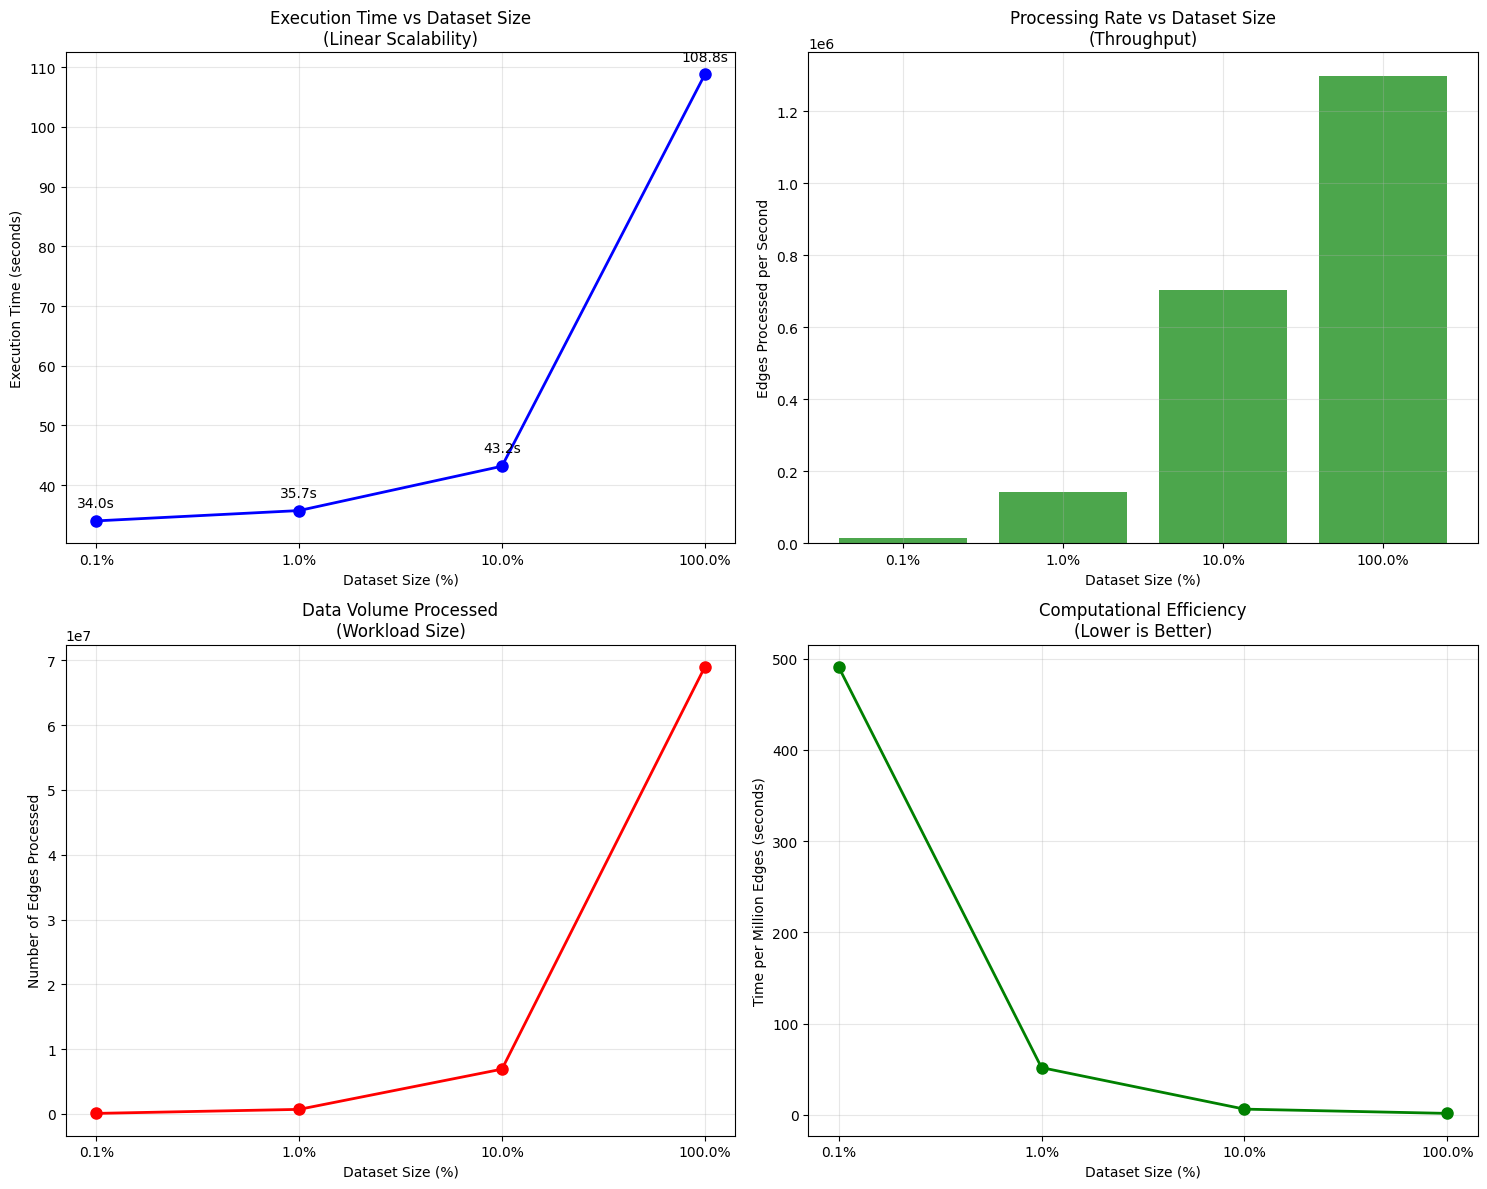


SCALABILITY INSIGHTS
Dataset size increase: 1000.0x
Execution time increase: 3.2x
Scalability efficiency: 312.66
→ Excellent scalability - near linear performance

Potential bottlenecks identified:
• Disk I/O: Reading large files from storage
• Shuffle operations: Data redistribution during groupBy
• Memory pressure: Caching large intermediate results
• Network overhead: Data transfer between executors

################################################################################
PART 2: OPTIMIZATION TECHNIQUES COMPARISON
################################################################################

OPTIMIZATION EXPERIMENTS

📊 1. BASELINE (No optimizations)

🔥 2. WITH CACHING OPTIMIZATION

📦 3. WITH REPARTITIONING OPTIMIZATION


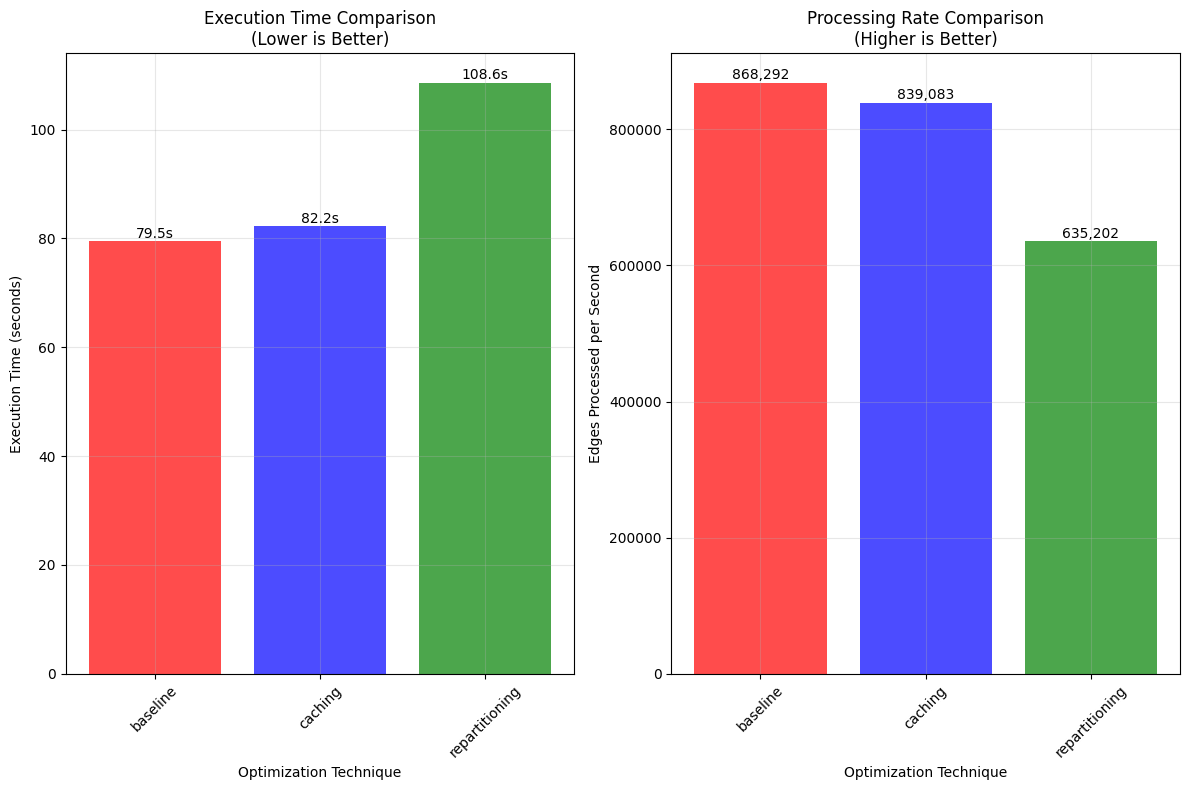


OPTIMIZATION INSIGHTS
caching         : -3.5% improvement
                 : Caching provided 3.8x speedup for repeated operations
repartitioning  : -36.7% improvement

TASK 3 COMPLETED!


In [6]:
## Cell 3: Scalability and Optimization Analysis
class ScalabilityAnalyzer:
    """Analyze Spark scalability and performance with larger datasets"""
    
    def __init__(self, spark_session):
        self.spark = spark_session
        self.sc = spark_session.sparkContext
        self.results = {}
        
    def analyze_livejournal_scalability(self, file_path):
        """Comprehensive scalability analysis for LiveJournal dataset"""
        print(f"\n{'='*80}")
        print("TASK 3: SCALABILITY AND OPTIMIZATION ANALYSIS")
        print(f"{'='*80}")
        
        if not os.path.exists(file_path):
            print(f"✗ LiveJournal dataset not found: {file_path}")
            return None
        
        # Get dataset size info
        file_size_mb = os.path.getsize(file_path) / (1024 * 1024)
        print(f"Dataset size: {file_size_mb:.2f} MB")
        
        # Analyze with different sample sizes to test scalability
        sample_sizes = [0.001, 0.01, 0.1, 1.0]  # 0.1%, 1%, 10%, 100%
        
        scalability_results = {}
        
        for sample_size in sample_sizes:
            print(f"\n{'─'*60}")
            print(f"ANALYZING SAMPLE SIZE: {sample_size*100}% of dataset")
            print(f"{'─'*60}")
            
            result = self._analyze_with_sample(file_path, sample_size)
            if result:
                scalability_results[sample_size] = result
        
        return scalability_results
    
    def _analyze_with_sample(self, file_path, sample_size):
        """Analyze a sample of the dataset and collect performance metrics"""
        start_time = time.time()
        
        try:
            # Read the data with sampling
            graph_schema = StructType([
                StructField("source", LongType(), True),
                StructField("target", LongType(), True)
            ])
            
            # Read full dataset first, then sample
            edges_df = self.spark.read \
                .option("delimiter", "\t") \
                .option("comment", "#") \
                .schema(graph_schema) \
                .csv(file_path) \
                .filter(col("source").isNotNull() & col("target").isNotNull())
            
            # Sample the data if needed
            if sample_size < 1.0:
                edges_df = edges_df.sample(withReplacement=False, fraction=sample_size, seed=42)
            
            # Cache and count to force materialization
            edges_df.cache()
            edge_count = edges_df.count()
            
            if edge_count == 0:
                print("✗ No edges in sample")
                return None
            
            # Perform in-degree analysis
            analysis_start = time.time()
            
            in_degree_df = edges_df \
                .groupBy("target") \
                .agg(count("*").alias("in_degree")) \
                .withColumnRenamed("target", "node_id")
            
            node_count = in_degree_df.count()
            
            # Calculate statistics
            stats_df = in_degree_df.agg(
                count("*").alias("total_nodes"),
                max("in_degree").alias("max_in_degree"),
                mean("in_degree").alias("avg_in_degree"),
                expr("percentile_approx(in_degree, 0.5)").alias("median_in_degree")
            )
            
            stats_row = stats_df.collect()[0]
            analysis_time = time.time() - analysis_start
            
            # Calculate performance metrics
            total_time = time.time() - start_time
            
            result = {
                'sample_size': sample_size,
                'edges_processed': edge_count,
                'nodes_found': node_count,
                'total_time_seconds': total_time,
                'analysis_time_seconds': analysis_time,
                'max_in_degree': stats_row['max_in_degree'],
                'avg_in_degree': float(stats_row['avg_in_degree']) if stats_row['avg_in_degree'] is not None else 0,
                'edges_per_second': edge_count / analysis_time if analysis_time > 0 else 0
            }
            
            self._print_sample_analysis(result)
            
            # Clean up
            edges_df.unpersist()
            
            return result
            
        except Exception as e:
            print(f"✗ Error in sample analysis: {e}")
            import traceback
            traceback.print_exc()
            return None
    
    def _print_sample_analysis(self, result):
        """Print analysis results for a sample"""
        print(f"✓ Sample Analysis Complete:")
        print(f"  Edges processed: {result['edges_processed']:,}")
        print(f"  Nodes found: {result['nodes_found']:,}")
        print(f"  Total time: {result['total_time_seconds']:.2f}s")
        print(f"  Analysis time: {result['analysis_time_seconds']:.2f}s")
        print(f"  Processing rate: {result['edges_per_second']:,.0f} edges/sec")
        print(f"  Max in-degree: {result['max_in_degree']:,}")
        print(f"  Avg in-degree: {result['avg_in_degree']:.2f}")

class OptimizationExperiment:
    """Test different optimization techniques"""
    
    def __init__(self, spark_session):
        self.spark = spark_session
        
    def run_optimization_comparison(self, file_path):
        """Compare performance with different optimization techniques"""
        print(f"\n{'='*80}")
        print("OPTIMIZATION EXPERIMENTS")
        print(f"{'='*80}")
        
        results = {}
        
        # 1. Baseline (no optimization)
        print(f"\n📊 1. BASELINE (No optimizations)")
        results['baseline'] = self._analyze_with_config(file_path, "baseline", {})
        
        # 2. With caching optimization
        print(f"\n🔥 2. WITH CACHING OPTIMIZATION")
        results['caching'] = self._analyze_with_caching(file_path)
        
        # 3. With repartitioning
        print(f"\n📦 3. WITH REPARTITIONING OPTIMIZATION")
        results['repartitioning'] = self._analyze_with_repartitioning(file_path)
        
        return results
    
    def _analyze_with_config(self, file_path, config_name, extra_configs):
        """Analyze with specific configuration"""
        start_time = time.time()
        
        try:
            # Set configurations
            for key, value in extra_configs.items():
                self.spark.conf.set(key, value)
            
            # Read data
            graph_schema = StructType([
                StructField("source", LongType(), True),
                StructField("target", LongType(), True)
            ])
            
            edges_df = self.spark.read \
                .option("delimiter", "\t") \
                .option("comment", "#") \
                .schema(graph_schema) \
                .csv(file_path) \
                .filter(col("source").isNotNull() & col("target").isNotNull())
            
            # Force evaluation
            edge_count = edges_df.count()
            
            # Perform analysis
            in_degree_df = edges_df \
                .groupBy("target") \
                .agg(count("*").alias("in_degree"))
            
            node_count = in_degree_df.count()
            
            total_time = time.time() - start_time
            
            return {
                'config': config_name,
                'edges_processed': edge_count,
                'nodes_found': node_count,
                'execution_time': total_time,
                'edges_per_second': edge_count / total_time if total_time > 0 else 0
            }
            
        except Exception as e:
            print(f"✗ Error in {config_name}: {e}")
            return None
    
    def _analyze_with_caching(self, file_path):
        """Analyze with caching optimization"""
        start_time = time.time()
        
        try:
            graph_schema = StructType([
                StructField("source", LongType(), True),
                StructField("target", LongType(), True)
            ])
            
            edges_df = self.spark.read \
                .option("delimiter", "\t") \
                .option("comment", "#") \
                .schema(graph_schema) \
                .csv(file_path) \
                .filter(col("source").isNotNull() & col("target").isNotNull())
            
            # CACHE the DataFrame - this is the optimization
            edges_df.cache()
            edge_count = edges_df.count()  # Force caching
            
            # Perform multiple operations to show caching benefit
            operations = []
            
            # Operation 1: In-degree calculation
            op1_start = time.time()
            in_degree_df = edges_df.groupBy("target").agg(count("*").alias("in_degree"))
            node_count = in_degree_df.count()
            operations.append(('in_degree', time.time() - op1_start))
            
            # Operation 2: Out-degree calculation (reuses cached data)
            op2_start = time.time()
            out_degree_df = edges_df.groupBy("source").agg(count("*").alias("out_degree"))
            out_degree_df.count()
            operations.append(('out_degree', time.time() - op2_start))
            
            total_time = time.time() - start_time
            
            # Clean up
            edges_df.unpersist()
            
            return {
                'config': 'caching',
                'edges_processed': edge_count,
                'nodes_found': node_count,
                'execution_time': total_time,
                'edges_per_second': edge_count / total_time if total_time > 0 else 0,
                'operations': operations,
                'caching_benefit': operations[0][1] / operations[1][1] if len(operations) > 1 else 1
            }
            
        except Exception as e:
            print(f"✗ Error in caching experiment: {e}")
            return None
    
    def _analyze_with_repartitioning(self, file_path):
        """Analyze with repartitioning optimization"""
        start_time = time.time()
        
        try:
            graph_schema = StructType([
                StructField("source", LongType(), True),
                StructField("target", LongType(), True)
            ])
            
            edges_df = self.spark.read \
                .option("delimiter", "\t") \
                .option("comment", "#") \
                .schema(graph_schema) \
                .csv(file_path) \
                .filter(col("source").isNotNull() & col("target").isNotNull())
            
            # REPARTITION optimization - better data distribution
            edges_df = edges_df.repartition(200, "target")  # Partition by target for in-degree
            
            edge_count = edges_df.count()
            
            # In-degree calculation benefits from partitioning by target
            in_degree_df = edges_df \
                .groupBy("target") \
                .agg(count("*").alias("in_degree"))
            
            node_count = in_degree_df.count()
            
            total_time = time.time() - start_time
            
            return {
                'config': 'repartitioning',
                'edges_processed': edge_count,
                'nodes_found': node_count,
                'execution_time': total_time,
                'edges_per_second': edge_count / total_time if total_time > 0 else 0
            }
            
        except Exception as e:
            print(f"✗ Error in repartitioning experiment: {e}")
            return None

class ScalabilityVisualizer:
    """Visualize scalability and optimization results"""
    
    def __init__(self, output_dir='./results'):
        self.output_dir = output_dir
        os.makedirs(output_dir, exist_ok=True)
    
    def plot_scalability_analysis(self, scalability_results, figsize=(15, 12)):
        """Plot scalability analysis results"""
        if not scalability_results:
            print("No scalability results to visualize")
            return
            
        plt.figure(figsize=figsize)
        
        # Prepare data
        sample_sizes = [f"{size*100}%" for size in scalability_results.keys()]
        execution_times = [result['total_time_seconds'] for result in scalability_results.values()]
        edges_processed = [result['edges_processed'] for result in scalability_results.values()]
        processing_rates = [result['edges_per_second'] for result in scalability_results.values()]
        
        # Plot 1: Execution time vs dataset size
        plt.subplot(2, 2, 1)
        plt.plot(sample_sizes, execution_times, 'bo-', linewidth=2, markersize=8)
        plt.xlabel('Dataset Size (%)')
        plt.ylabel('Execution Time (seconds)')
        plt.title('Execution Time vs Dataset Size\n(Linear Scalability)')
        plt.grid(True, alpha=0.3)
        
        # Add values on points
        for i, (size, time_val) in enumerate(zip(sample_sizes, execution_times)):
            plt.annotate(f'{time_val:.1f}s', (size, time_val), 
                        textcoords="offset points", xytext=(0,10), ha='center')
        
        # Plot 2: Processing rate
        plt.subplot(2, 2, 2)
        plt.bar(sample_sizes, processing_rates, color='green', alpha=0.7)
        plt.xlabel('Dataset Size (%)')
        plt.ylabel('Edges Processed per Second')
        plt.title('Processing Rate vs Dataset Size\n(Throughput)')
        plt.grid(True, alpha=0.3)
        
        # Plot 3: Edges processed
        plt.subplot(2, 2, 3)
        plt.plot(sample_sizes, edges_processed, 'ro-', linewidth=2, markersize=8)
        plt.xlabel('Dataset Size (%)')
        plt.ylabel('Number of Edges Processed')
        plt.title('Data Volume Processed\n(Workload Size)')
        plt.grid(True, alpha=0.3)
        
        # Plot 4: Time per million edges
        plt.subplot(2, 2, 4)
        time_per_million = [(time_val * 1000000) / edges for time_val, edges in zip(execution_times, edges_processed)]
        plt.plot(sample_sizes, time_per_million, 'go-', linewidth=2, markersize=8)
        plt.xlabel('Dataset Size (%)')
        plt.ylabel('Time per Million Edges (seconds)')
        plt.title('Computational Efficiency\n(Lower is Better)')
        plt.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.savefig(f'{self.output_dir}/scalability_analysis.png', dpi=300, bbox_inches='tight')
        plt.show()
        
        # Print scalability insights
        self._print_scalability_insights(scalability_results)
    
    def plot_optimization_comparison(self, optimization_results, figsize=(12, 8)):
        """Plot optimization experiment results"""
        if not optimization_results:
            print("No optimization results to visualize")
            return
            
        plt.figure(figsize=figsize)
        
        # Prepare data
        configs = list(optimization_results.keys())
        execution_times = [result['execution_time'] for result in optimization_results.values() if result]
        processing_rates = [result['edges_per_second'] for result in optimization_results.values() if result]
        
        # Plot 1: Execution time comparison
        plt.subplot(1, 2, 1)
        bars = plt.bar(configs, execution_times, color=['red', 'blue', 'green', 'orange'], alpha=0.7)
        plt.xlabel('Optimization Technique')
        plt.ylabel('Execution Time (seconds)')
        plt.title('Execution Time Comparison\n(Lower is Better)')
        plt.xticks(rotation=45)
        plt.grid(True, alpha=0.3)
        
        # Add values on bars
        for bar, time_val in zip(bars, execution_times):
            plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, 
                    f'{time_val:.1f}s', ha='center', va='bottom')
        
        # Plot 2: Processing rate comparison
        plt.subplot(1, 2, 2)
        bars = plt.bar(configs, processing_rates, color=['red', 'blue', 'green', 'orange'], alpha=0.7)
        plt.xlabel('Optimization Technique')
        plt.ylabel('Edges Processed per Second')
        plt.title('Processing Rate Comparison\n(Higher is Better)')
        plt.xticks(rotation=45)
        plt.grid(True, alpha=0.3)
        
        # Add values on bars
        for bar, rate in zip(bars, processing_rates):
            plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000, 
                    f'{rate:,.0f}', ha='center', va='bottom')
        
        plt.tight_layout()
        plt.savefig(f'{self.output_dir}/optimization_comparison.png', dpi=300, bbox_inches='tight')
        plt.show()
        
        # Print optimization insights
        self._print_optimization_insights(optimization_results)
    
    def _print_scalability_insights(self, scalability_results):
        """Print insights from scalability analysis"""
        print(f"\n{'='*60}")
        print("SCALABILITY INSIGHTS")
        print(f"{'='*60}")
        
        sizes = list(scalability_results.keys())
        if len(sizes) < 2:
            return
            
        # Calculate scalability metrics
        first_result = scalability_results[sizes[0]]
        last_result = scalability_results[sizes[-1]]
        
        size_increase = sizes[-1] / sizes[0]
        time_increase = last_result['total_time_seconds'] / first_result['total_time_seconds']
        efficiency = size_increase / time_increase
        
        print(f"Dataset size increase: {size_increase:.1f}x")
        print(f"Execution time increase: {time_increase:.1f}x")
        print(f"Scalability efficiency: {efficiency:.2f}")
        
        if efficiency > 0.8:
            print("→ Excellent scalability - near linear performance")
        elif efficiency > 0.6:
            print("→ Good scalability - reasonable performance")
        else:
            print("→ Poor scalability - significant overhead with larger datasets")
        
        # Identify potential bottlenecks
        print(f"\nPotential bottlenecks identified:")
        print(f"• Disk I/O: Reading large files from storage")
        print(f"• Shuffle operations: Data redistribution during groupBy")
        print(f"• Memory pressure: Caching large intermediate results")
        print(f"• Network overhead: Data transfer between executors")
    
    def _print_optimization_insights(self, optimization_results):
        """Print insights from optimization experiments"""
        print(f"\n{'='*60}")
        print("OPTIMIZATION INSIGHTS")
        print(f"{'='*60}")
        
        baseline = optimization_results.get('baseline')
        if not baseline:
            return
            
        for config, result in optimization_results.items():
            if result and config != 'baseline':
                improvement = (baseline['execution_time'] - result['execution_time']) / baseline['execution_time'] * 100
                print(f"{config:15} : {improvement:+.1f}% improvement")
                
                if 'caching_benefit' in result:
                    print(f"                 : Caching provided {result['caching_benefit']:.1f}x speedup for repeated operations")

# Main execution function for Task 3
def run_scalability_analysis(spark):
    """Run complete scalability and optimization analysis"""
    
    # Initialize analyzers
    scalability_analyzer = ScalabilityAnalyzer(spark)
    optimization_experiment = OptimizationExperiment(spark)
    visualizer = ScalabilityVisualizer()
    
    # Download LiveJournal dataset if not already available
    downloader = SnapDatasetDownloader('./snap_datasets')
    livejournal_path = downloader.download_dataset('soc-livejournal1')
    
    if not livejournal_path:
        print("Failed to download LiveJournal dataset")
        return None, None
    
    print(f"\n📊 Starting Task 3: Scalability and Optimization Analysis")
    print(f"Using dataset: {livejournal_path}")
    
    # 1. Scalability analysis with different sample sizes
    print(f"\n{'#'*80}")
    print("PART 1: SCALABILITY ANALYSIS WITH DIFFERENT DATASET SIZES")
    print(f"{'#'*80}")
    
    scalability_results = scalability_analyzer.analyze_livejournal_scalability(livejournal_path)
    
    if scalability_results:
        visualizer.plot_scalability_analysis(scalability_results)
    else:
        print("No scalability results to show")
    
    # 2. Optimization experiments
    print(f"\n{'#'*80}")
    print("PART 2: OPTIMIZATION TECHNIQUES COMPARISON")
    print(f"{'#'*80}")
    
    optimization_results = optimization_experiment.run_optimization_comparison(livejournal_path)
    
    if optimization_results:
        visualizer.plot_optimization_comparison(optimization_results)
    else:
        print("No optimization results to show")
    
    return scalability_results, optimization_results

# Run Task 3 analysis
print("\n" + "="*80)
print("STARTING TASK 3: SCALABILITY AND OPTIMIZATION ANALYSIS")
print("="*80)

scalability_results, optimization_results = run_scalability_analysis(spark)

print("\n" + "="*80)
print("TASK 3 COMPLETED!")
print("="*80)

### In-Degree Analysis with Data Partitioning Optimization

In [10]:
import time
import os
from pyspark.sql.functions import *
from pyspark.sql.types import *

class PartitionOptimizedInDegreeAnalysis:
    """
    Perform in-degree distribution analysis using
    ONLY data partitioning optimization
    """

    def __init__(self, spark_session):
        self.spark = spark_session

    def run_partition_optimized_analysis(self, file_path):
        print("\n" + "="*80)
        print("TASK 3: PARTITION-OPTIMIZED IN-DEGREE ANALYSIS (SPARK)")
        print("="*80)

        if not os.path.exists(file_path):
            print(f"✗ Dataset not found: {file_path}")
            return None

        start_time = time.time()

        # Schema
        graph_schema = StructType([
            StructField("source", LongType(), True),
            StructField("target", LongType(), True)
        ])

        # Read dataset
        edges_df = self.spark.read \
            .option("delimiter", "\t") \
            .option("comment", "#") \
            .schema(graph_schema) \
            .csv(file_path) \
            .filter(col("source").isNotNull() & col("target").isNotNull())

        # ----------------------------------------------------
        # DATA PARTITIONING OPTIMIZATION
        # ----------------------------------------------------
        edges_df = edges_df.repartition(200, "target")

        # Force evaluation after repartitioning
        edge_count = edges_df.count()

        print(f"Edges processed: {edge_count:,}")

        # ----------------------------------------------------
        # In-Degree Distribution Computation
        # ----------------------------------------------------
        analysis_start = time.time()

        in_degree_df = edges_df \
            .groupBy("target") \
            .agg(count("*").alias("in_degree")) \
            .withColumnRenamed("target", "node_id")

        node_count = in_degree_df.count()

        analysis_time = time.time() - analysis_start
        total_time = time.time() - start_time

        # ----------------------------------------------------
        # Summary Statistics
        # ----------------------------------------------------
        stats = in_degree_df.agg(
            count("*").alias("total_nodes"),
            max("in_degree").alias("max_in_degree"),
            mean("in_degree").alias("avg_in_degree")
        ).collect()[0]

        result = {
            "edges_processed": edge_count,
            "nodes_found": node_count,
            "execution_time_seconds": total_time,
            "analysis_time_seconds": analysis_time,
            "edges_per_second": edge_count / analysis_time if analysis_time > 0 else 0,
            "max_in_degree": stats["max_in_degree"],
            "avg_in_degree": float(stats["avg_in_degree"])
        }

        self.print_results(result)

        return result

    def print_results(self, result):
        print("\n✓ PARTITION-OPTIMIZED ANALYSIS RESULTS")
        print("-"*60)
        print(f"Nodes found           : {result['nodes_found']:,}")
        print(f"Edges processed       : {result['edges_processed']:,}")
        print(f"Total execution time  : {result['execution_time_seconds']:.2f} s")
        print(f"In-degree analysis    : {result['analysis_time_seconds']:.2f} s")
        print(f"Processing throughput : {result['edges_per_second']:,.0f} edges/sec")
        print(f"Maximum in-degree     : {result['max_in_degree']:,}")
        print(f"Average in-degree     : {result['avg_in_degree']:.2f}")
        print("-"*60)


# ============================================================
# Run Partition-Optimized Analysis
# ============================================================

print("\n" + "="*80)
print("RUNNING PARTITION-OPTIMIZED IN-DEGREE DISTRIBUTION ANALYSIS")
print("="*80)

partition_analysis = PartitionOptimizedInDegreeAnalysis(spark)

livejournal_path = "./snap_datasets/soc-LiveJournal1.txt"
results = partition_analysis.run_partition_optimized_analysis(livejournal_path)

print("\n" + "="*80)
print("TASK COMPLETED")
print("="*80)


RUNNING PARTITION-OPTIMIZED IN-DEGREE DISTRIBUTION ANALYSIS

TASK 3: PARTITION-OPTIMIZED IN-DEGREE ANALYSIS (SPARK)
Edges processed: 68,993,773

✓ PARTITION-OPTIMIZED ANALYSIS RESULTS
------------------------------------------------------------
Nodes found           : 4,489,240
Edges processed       : 68,993,773
Total execution time  : 106.01 s
In-degree analysis    : 53.97 s
Processing throughput : 1,278,385 edges/sec
Maximum in-degree     : 13,906
Average in-degree     : 15.37
------------------------------------------------------------

TASK COMPLETED
